# Strain-Gauge Thermal Correction — Methodology Walkthrough

Removing thermal output (apparent strain) from measured strain so the recovered **mechanical** strain can be validated against an FE model. Runs the real tool functions on synthetic data — no ANSYS required.

## 1 · Pipeline at a glance

`measured` → subtract `apparent(T)` → rescale by `F_ref/F(T)` → `mechanical` → overlay vs FE elastic strain.

In [1]:
# ▶ Setup — import the REAL tool functions (no ANSYS required)
import sys, pathlib, json, tempfile
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = pathlib.Path.cwd()
while not (ROOT / "scripts" / "strain_gauge_thermal_correction").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from scripts.strain_gauge_thermal_correction import core, config

NAVY, ORANGE, RED, GREEN = "#1F4E79", "#C55A11", "#b3261e", "#2e7d32"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.titleweight": "bold", "figure.figsize": (8.2, 3.6)})
rng = np.random.default_rng(20260630)
print("tool loaded from:", ROOT / "scripts" / "strain_gauge_thermal_correction")

tool loaded from: <repo-root>\scripts\strain_gauge_thermal_correction


## 2 · Theory

A bonded gauge on an **unloaded** part still reports strain when temperature changes — the
**thermal output** (apparent strain). To recover the **mechanical** strain that the FE model
predicts, subtract it and rescale for gauge-factor drift:

$$\varepsilon_{\text{mech}}(t) = \Big[\varepsilon_{\text{meas}}(t) - \varepsilon_{\text{app}}\big(T(t)\big)\Big]\,\frac{F_{\text{ref}}}{F\big(T(t)\big)}$$

$$\varepsilon_{\text{app}}(T) = \underbrace{\text{curve}(T)}_{\text{manufacturer fit}} \; + \; \underbrace{(\alpha_{\text{part}} - \alpha_{\text{curve}})\,(T - T_{\text{ref}})}_{\text{substrate mismatch}}, \qquad F(T) = F_{\text{ref}}\Big(1 + \tfrac{\Delta F(T)}{100}\Big)$$

**Self-temperature compensation (STC).** The gauge `BAB350-…(16)…` is processed so its thermal
output is ~0 on a substrate with $\alpha \approx 16\,\text{ppm}/^\circ\text{C}$ (copper). A curve
from the *gauge maker* is that **copper-reference** curve. The part here is **titanium**
($\alpha \approx 9$), so an extra $(\alpha_{\text{Ti}} - 16)\,\Delta T \approx -7\,\Delta T$ ppm
of apparent strain appears and **must** be added — the *substrate mismatch* term.

## 3 · Load and fit the manufacturer curve

`core.load_curve` fits a polynomial (default degree 1) and reports $R^2$, mirroring the repo's
`miso_curve_builder` fit-reporting style.

fit: slope=1.1008 ue/degC  intercept=-22.200 ue  R^2=0.99999  rmse=0.353 ue


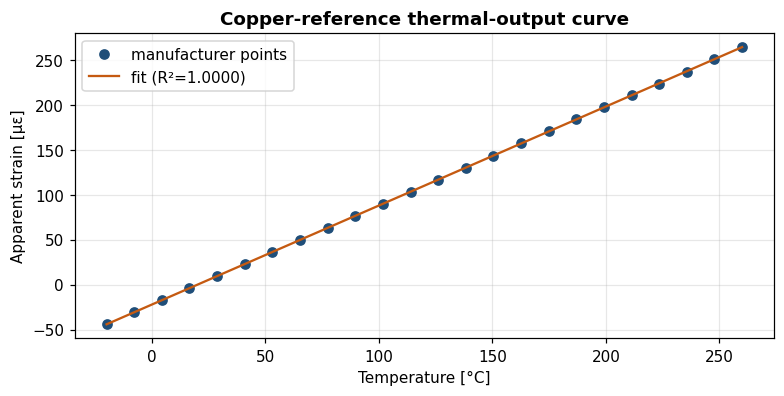

In [2]:
# ▶ Runnable demo — synthesize a near-flat copper-reference curve and fit it with the real loader
T_REF, M_CU = 20.0, 1.1                      # copper-reference slope, ppm/degC
t_curve = np.linspace(-20, 260, 24)
eps_curve = M_CU * (t_curve - T_REF) + rng.normal(0, 0.4, t_curve.size)   # tiny noise -> R^2 ~ 0.999
curve_csv = pathlib.Path(tempfile.mkdtemp()) / "copper_reference_curve.csv"
pd.DataFrame({"Temperature_C": t_curve, "ApparentStrain_ue": eps_curve}).to_csv(curve_csv, index=False)

fit = core.load_curve(curve_csv, degree=1)
print(f"fit: slope={fit.coeffs[0]:.4f} ue/degC  intercept={fit.coeffs[1]:.3f} ue  "
      f"R^2={fit.r_squared:.5f}  rmse={fit.rmse:.3f} ue")

fig, ax = plt.subplots()
tt = np.linspace(-20, 260, 200)
ax.plot(t_curve, eps_curve, "o", color=NAVY, label="manufacturer points")
ax.plot(tt, np.polyval(fit.coeffs, tt), "-", color=ORANGE, label=f"fit (R²={fit.r_squared:.4f})")
ax.set(title="Copper-reference thermal-output curve", xlabel="Temperature [°C]", ylabel="Apparent strain [µε]")
ax.legend(); plt.show()

## 4 · Apparent strain on titanium — the substrate mismatch

`core.apparent_strain` evaluates the fitted curve **plus** the mismatch term. Toggling
`mismatch_enabled` shows why a copper-reference curve cannot be used as-is on titanium.

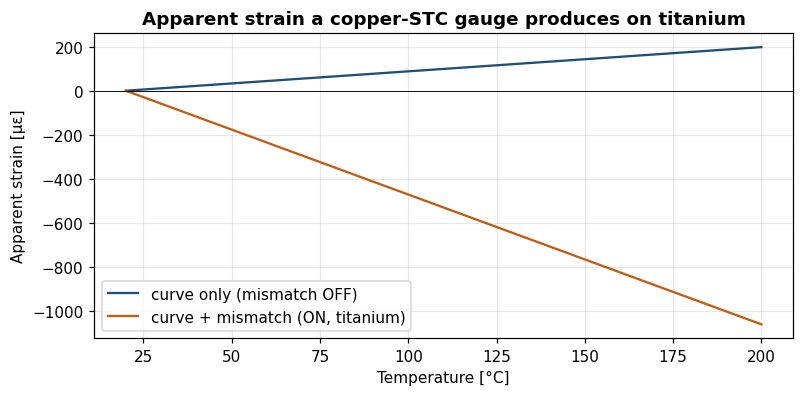

at 170 °C: mismatch adds -1051 µε


In [3]:
# ▶ Runnable demo — apparent strain on titanium, mismatch ON vs OFF
T = np.linspace(20, 200, 200)
cfg_on  = config.CorrectionConfig(t_ref_celsius=T_REF, mismatch_enabled=True,  alpha_part_ppm=9.0, alpha_curve_substrate_ppm=16.0)
cfg_off = config.CorrectionConfig(t_ref_celsius=T_REF, mismatch_enabled=False)

app_on  = core.apparent_strain(T, fit, cfg_on)
app_off = core.apparent_strain(T, fit, cfg_off)

fig, ax = plt.subplots()
ax.plot(T, app_off, color=NAVY,   label="curve only (mismatch OFF)")
ax.plot(T, app_on,  color=ORANGE, label="curve + mismatch (ON, titanium)")
ax.axhline(0, color="k", lw=0.6)
ax.set(title="Apparent strain a copper-STC gauge produces on titanium",
       xlabel="Temperature [°C]", ylabel="Apparent strain [µε]")
ax.legend(); plt.show()
print(f"at 170 °C: mismatch adds {app_on[np.argmin(abs(T-170))]-app_off[np.argmin(abs(T-170))]:.0f} µε")

## 5 · Gauge-factor variation with temperature

The instrument is set to $F_{\text{ref}}$; the true gauge factor drifts with temperature.
`core.gauge_factor_scale` returns $F_{\text{ref}}/F(T)=1/(1+\Delta F/100)$ (identity if no data).

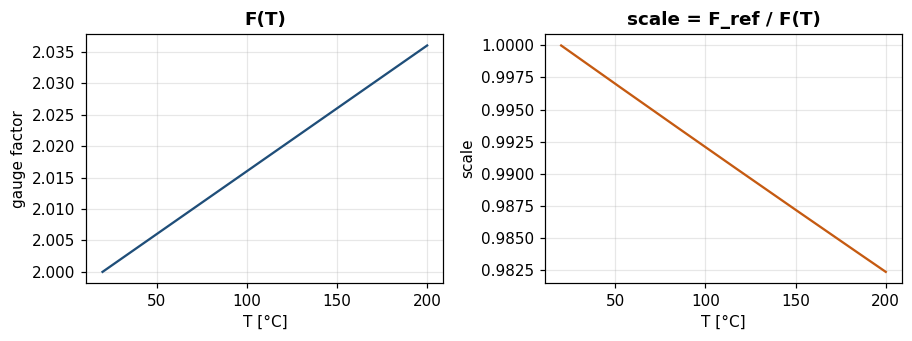

In [4]:
# ▶ Runnable demo — F(T) and the correction scale
cfg_gf = config.CorrectionConfig(gauge_factor_ref=2.0, gauge_factor_delta_pct=0.01)   # 0.01 %/degC
F = core.gauge_factor(T, cfg_gf)
scale = core.gauge_factor_scale(T, cfg_gf)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.4, 3.2))
a1.plot(T, F, color=NAVY); a1.set(title="F(T)", xlabel="T [°C]", ylabel="gauge factor")
a2.plot(T, scale, color=ORANGE); a2.set(title="scale = F_ref / F(T)", xlabel="T [°C]", ylabel="scale")
plt.tight_layout(); plt.show()

## 6 · Ground-truth round trip

Fabricate a **known** mechanical strain, build a synthetic *measured* signal through the forward
model, then run the real `core.correct_dataset` and confirm it recovers the truth.

max |recovered - truth| = 0.183 µε   (uncorrected bias was up to 887 µε)


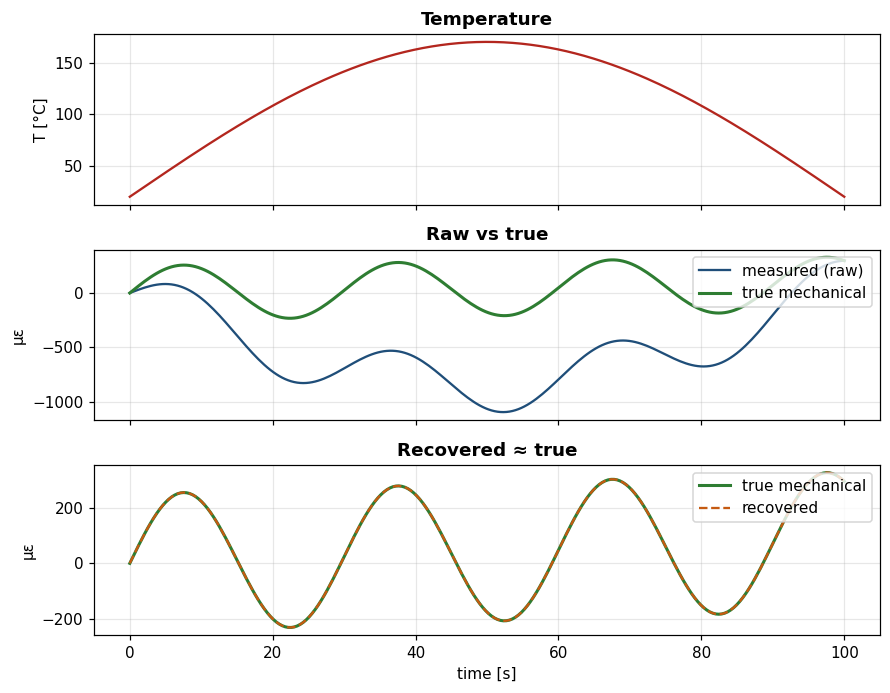

In [5]:
# ▶ Runnable demo — recover a known mechanical strain
ALPHA_PART, ALPHA_CURVE = 9.0, 16.0
GF_SLOPE = 0.008
time = np.linspace(0, 100, 240)
temperature = T_REF + (170 - T_REF) * np.sin(np.pi * time / time[-1])
eps_mech_true = 250 * np.sin(2*np.pi*time/30) + 0.8*time
eps_app_true  = M_CU*(temperature-T_REF) + (ALPHA_PART-ALPHA_CURVE)*(temperature-T_REF)
measured      = eps_mech_true*(1 + GF_SLOPE*(temperature-T_REF)/100) + eps_app_true

strain_df = pd.DataFrame({"Time": time, "SG01": measured})
temp_df   = pd.DataFrame({"Time": time, "SG01": temperature})
cfg = config.CorrectionConfig(t_ref_celsius=T_REF, mismatch_enabled=True,
                              alpha_part_ppm=ALPHA_PART, alpha_curve_substrate_ppm=ALPHA_CURVE,
                              gauge_factor_delta_pct=GF_SLOPE)
corrected, apparent, diag = core.correct_dataset(strain_df, temp_df, fit, cfg)
recovered = corrected["SG01"].to_numpy(float)
print(f"max |recovered - truth| = {np.max(np.abs(recovered-eps_mech_true)):.3f} µε   "
      f"(uncorrected bias was up to {np.max(np.abs(measured-eps_mech_true)):.0f} µε)")

fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(8.2, 6.4), sharex=True)
a1.plot(time, temperature, color=RED); a1.set(ylabel="T [°C]", title="Temperature")
a2.plot(time, measured, color=NAVY, label="measured (raw)")
a2.plot(time, eps_mech_true, color=GREEN, lw=2, label="true mechanical")
a2.set(ylabel="µε", title="Raw vs true"); a2.legend(loc="upper right")
a3.plot(time, eps_mech_true, color=GREEN, lw=2, label="true mechanical")
a3.plot(time, recovered, "--", color=ORANGE, label="recovered")
a3.set(ylabel="µε", xlabel="time [s]", title="Recovered ≈ true"); a3.legend(loc="upper right")
plt.tight_layout(); plt.show()

### ⚠️ The silent trap — omitting the mismatch term

A copper-reference curve looks almost flat, so it is tempting to "just subtract the curve" and
skip the mismatch term. On titanium that leaves a temperature-shaped residual of ~1000 µε —
larger than the mechanical strains you are trying to validate, and it would silently corrupt the
FE correlation.

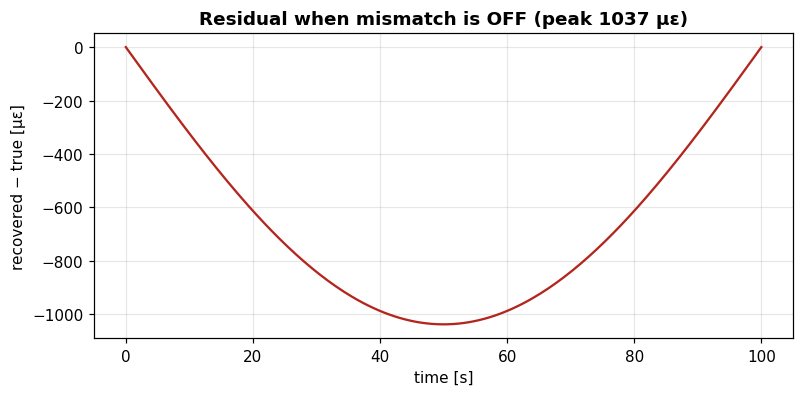

peak error from omitting mismatch: 1037 µε


In [6]:
# ▶ Runnable demo — same data, mismatch OFF
cfg_wrong = config.CorrectionConfig(t_ref_celsius=T_REF, mismatch_enabled=False,
                                    gauge_factor_delta_pct=GF_SLOPE)
recovered_wrong = core.correct_dataset(strain_df, temp_df, fit, cfg_wrong)[0]["SG01"].to_numpy(float)
residual = recovered_wrong - eps_mech_true
fig, ax = plt.subplots()
ax.plot(time, residual, color=RED)
ax.set(title=f"Residual when mismatch is OFF (peak {np.max(np.abs(residual)):.0f} µε)",
       xlabel="time [s]", ylabel="recovered − true [µε]")
plt.show()
print(f"peak error from omitting mismatch: {np.max(np.abs(residual)):.0f} µε")

## 7 · CSV outputs feed the existing toolchain

The corrected-strain CSV passes the Sensor Comparison Tool's `validate_dataset_frame`, and the
apparent-strain CSV matches the `channel_matrix_from_csv` contract the load-reconstruction tool
uses (it selects channels **by name**). The contract is reproduced inline below because the
original lives in an IronPython Mechanical script.

In [7]:
# ▶ Runnable demo — write the two CSVs and re-read them through the downstream contracts
out = pathlib.Path(tempfile.mkdtemp())
corrected_path = core.write_corrected_strain_csv(out / "corrected_strain.csv", corrected)
thermal_path   = core.write_thermal_apparent_csv(out / "SG_thermal_apparent_strain_data.csv", apparent)

def channel_matrix_from_csv(path, channel_names, target_rows):     # vendored contract
    df = pd.read_csv(path)
    if all(c in df.columns for c in channel_names):
        values = df.loc[:, channel_names].astype(float).values
    elif df.shape[1] == len(channel_names) + 1:
        values = df.iloc[:, 1:].astype(float).values
    else:
        values = df.iloc[:, :].astype(float).values
    if values.shape[0] == 1 and target_rows > 1:
        values = np.repeat(values, target_rows, axis=0)
    assert values.shape == (target_rows, len(channel_names)) and np.all(np.isfinite(values))
    return values

mat = channel_matrix_from_csv(thermal_path, ["SG01"], target_rows=len(time))
print("apparent matrix for load reconstruction:", mat.shape, "finite:", np.isfinite(mat).all())
print(pd.read_csv(corrected_path).head(3).to_string(index=False))

apparent matrix for load reconstruction: (240, 1) finite: True
   Time      SG01
0.00000  0.183458
0.41841 22.396354
0.83682 44.441335


## 8 · Diagnostics & trust checklist

Every run emits a JSON record of the fit, the α values, the units, per-channel max apparent
strain, and a **trust checklist** of items to confirm before believing the numbers.

In [8]:
# ▶ Runnable demo — inspect the diagnostics
print(json.dumps({k: diag[k] for k in ("model", "curve_fit", "units")}, indent=2))
print("\nTrust checklist:")
for item in diag["trust_checklist"]:
    print(" -", item)

{
  "model": {
    "equation": "eps_mech = (eps_measured - eps_apparent) * F_ref/F(T); eps_apparent = curve_fit(T) + (alpha_part - alpha_curve)*(T - T_ref)",
    "t_ref_celsius": 20.0,
    "mismatch_enabled": true,
    "alpha_part_ppm_per_C": 9.0,
    "alpha_curve_substrate_ppm_per_C": 16.0,
    "gauge_factor_correction_applied": true
  },
  "curve_fit": {
    "source": "csv",
    "degree": 1,
    "coeffs_microstrain_vs_T_highest_power_first": [
      1.1008490794716246,
      -22.20044004784368
    ],
    "r_squared": 0.9999855217233102,
    "rmse_microstrain": 0.35299037059117183,
    "t_min_celsius": -20.0,
    "t_max_celsius": 260.0,
    "n_points": 24
  },
  "units": {
    "measured": "microstrain",
    "curve": "microstrain",
    "output": "microstrain",
    "internal": "microstrain"
  }
}

Trust checklist:
 - Confirm with the gauge maker which substrate the thermal-output curve was measured on (copper/STC reference vs your titanium part); it decides whether the mismatch term app

## 9 · Limitations & assumptions

- **Curve substrate is the decisive input.** Copper-reference curve ⇒ mismatch ON (this case);
  curve measured on the real titanium part ⇒ `--no-mismatch`. Confirm with the gauge maker.
- The mismatch term is large, so use the **exact reference α**, the curve's **reference
  temperature**, and **α(T)** for the specific Ti alloy.
- **Units**: a stray ×10⁶ corrupts the FE comparison; set `output_unit` to match your
  `SG_FEA_strain_data.csv`.
- Compare against FE **elastic** strain **projected onto the gauge axis** — that projection is
  done by the existing strain-projection / Sensor Comparison steps, not this tool.